In [ ]:
import numpy as np
import scipy
import torch
import torch.nn as nn
from torchdiffeq import odeint as torchodeint
from tqdm import tqdm
import matplotlib.pyplot as plt

import os, sys
module_path = os.path.abspath(os.path.join('..'))
sys.path.append(module_path+"\\KAN_variants")
from ChebyKANLayer import ChebyKAN

module_path = os.path.abspath(os.path.join('..'))
sys.path.append(module_path+"\\code")
from myKANODE import KANODE

In [ ]:
model = ChebyKAN([2, 10, 2], 4)

In [ ]:
def pred_prey_deriv(X, t, alpha, beta, delta, gamma):
    x=X[0]
    y=X[1]
    dxdt = alpha*x-beta*x*y
    dydt = delta*x*y-gamma*y
    dXdt=[dxdt, dydt]
    return dXdt

#alpha=1.5
#beta=1
#gamma=2
#delta=1
#x0 = 1
#y0 = 1

ICs: tensor([[0.5000, 1.5000]], requires_grad=True)


100%|██████████| 1000/1000 [11:08<00:00,  1.50it/s]


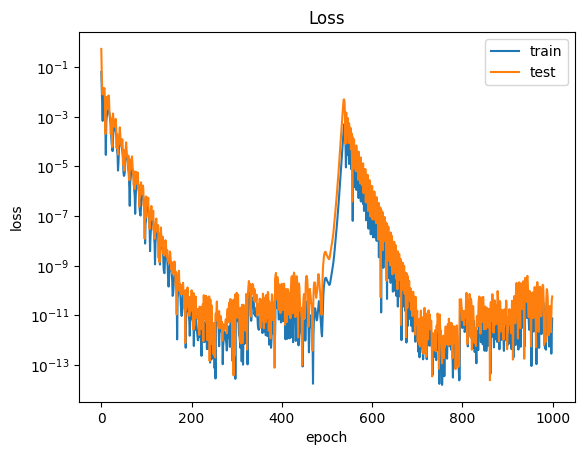

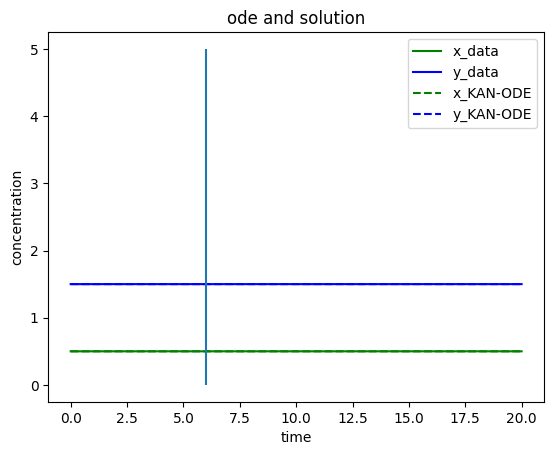

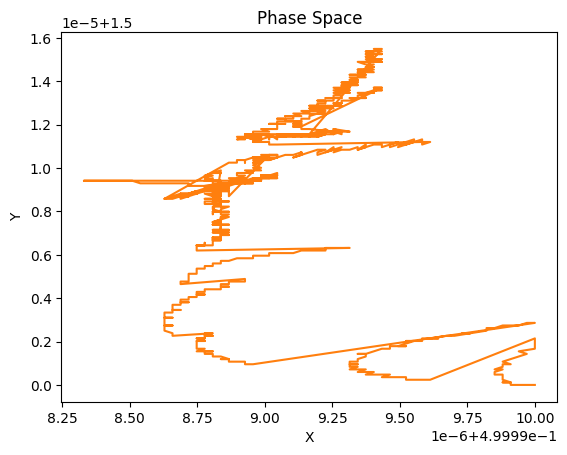

ICs: tensor([[0.4444, 1.5000]], requires_grad=True)


100%|██████████| 1000/1000 [15:29<00:00,  1.08it/s]


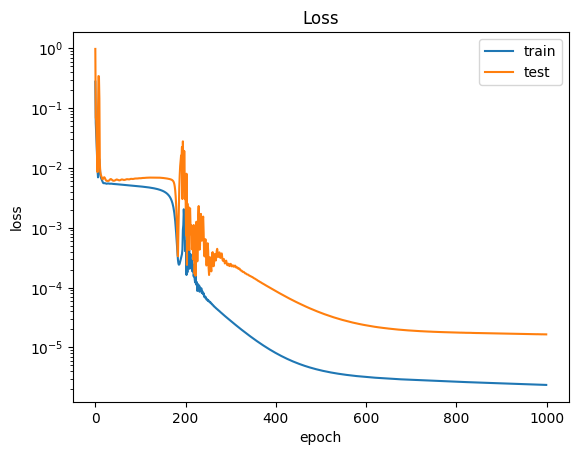

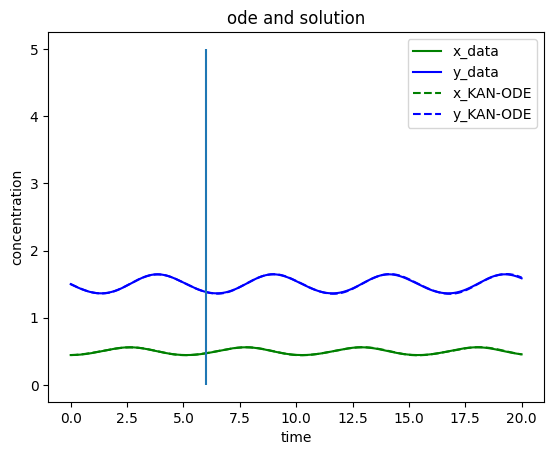

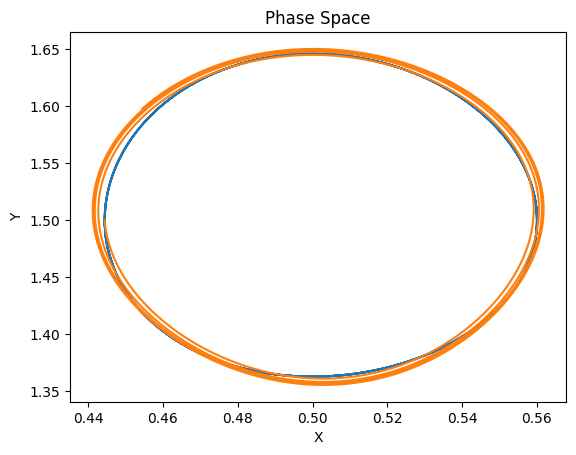

ICs: tensor([[0.3889, 1.5000]], requires_grad=True)


100%|██████████| 1000/1000 [17:24<00:00,  1.04s/it]


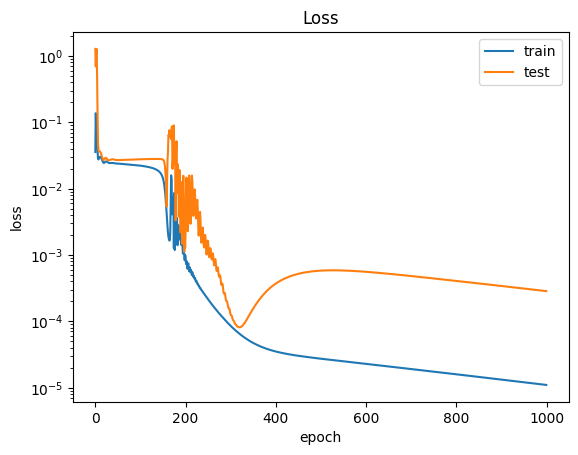

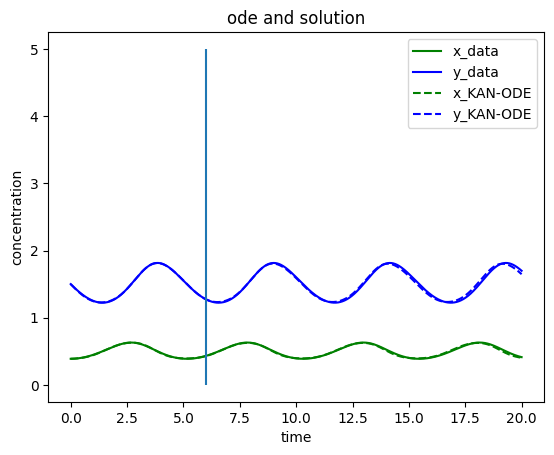

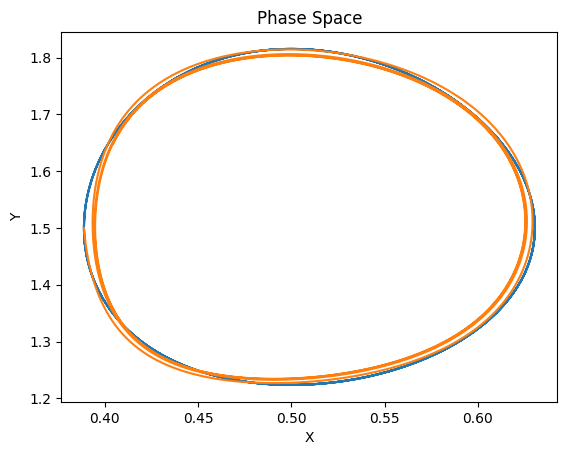

ICs: tensor([[0.3333, 1.5000]], requires_grad=True)


100%|██████████| 1000/1000 [18:49<00:00,  1.13s/it]


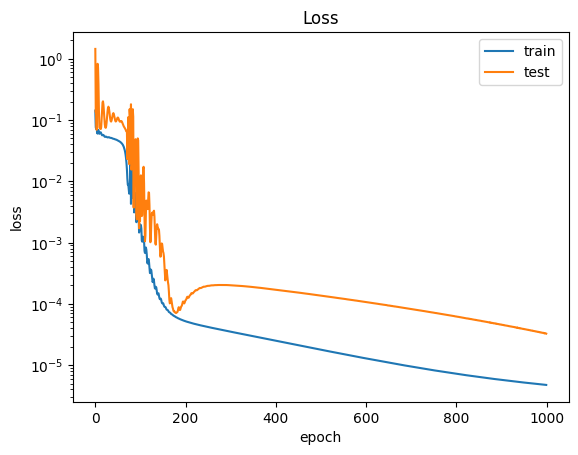

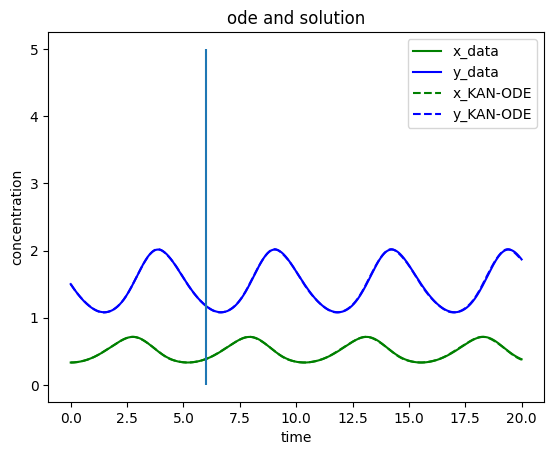

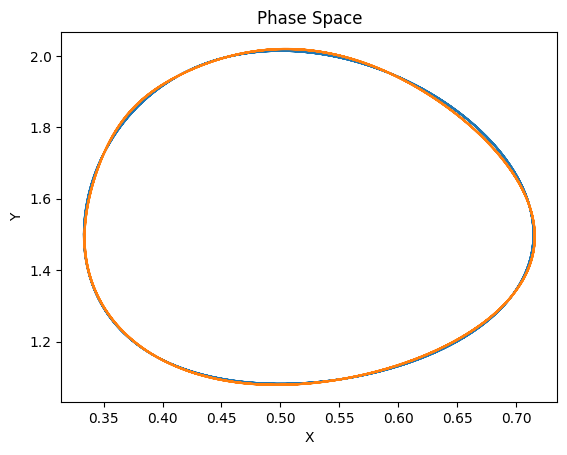

ICs: tensor([[0.2778, 1.5000]], requires_grad=True)


100%|██████████| 1000/1000 [21:06<00:00,  1.27s/it]


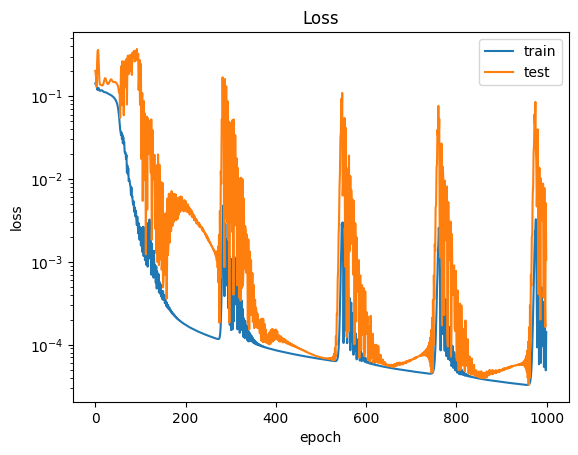

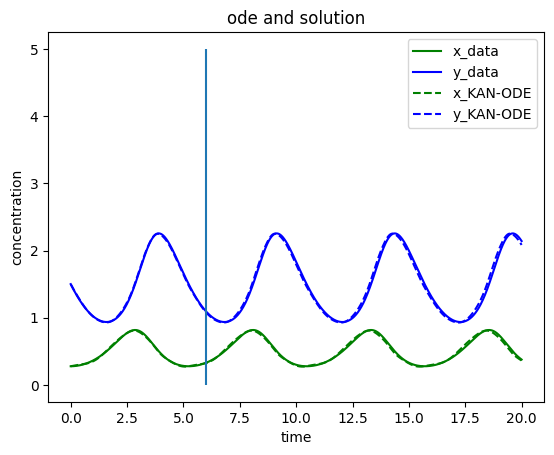

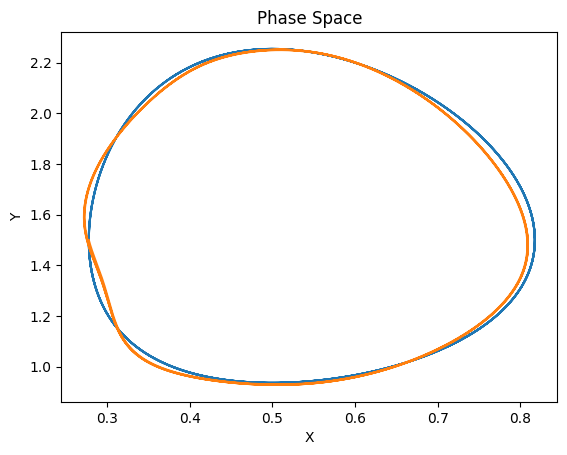

ICs: tensor([[0.2222, 1.5000]], requires_grad=True)


100%|██████████| 1000/1000 [22:36<00:00,  1.36s/it]


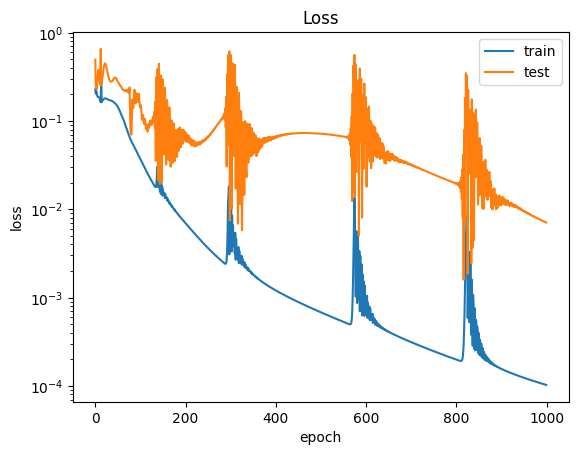

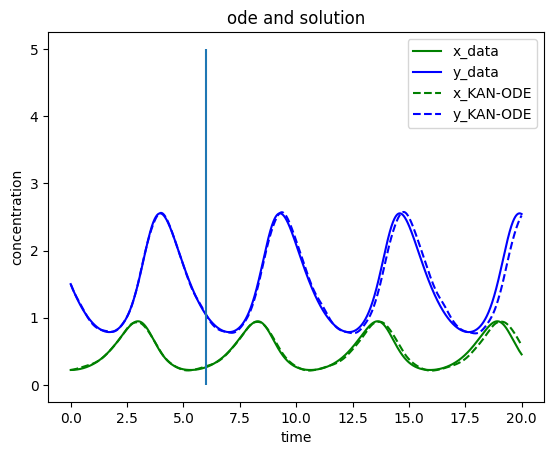

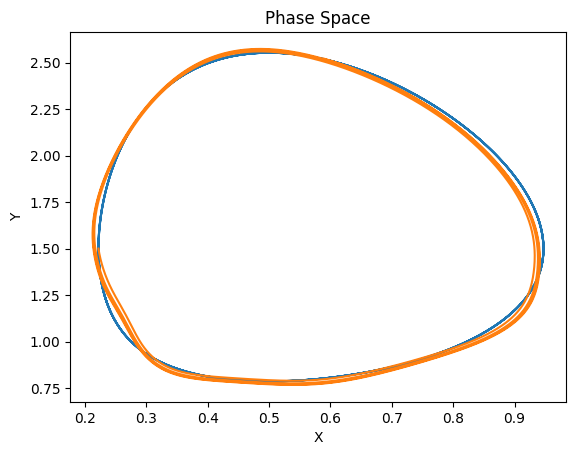

ICs: tensor([[0.1667, 1.5000]], requires_grad=True)


100%|██████████| 1000/1000 [24:13<00:00,  1.45s/it]


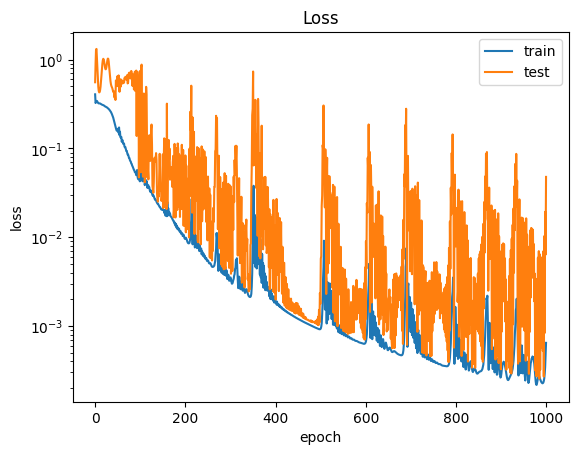

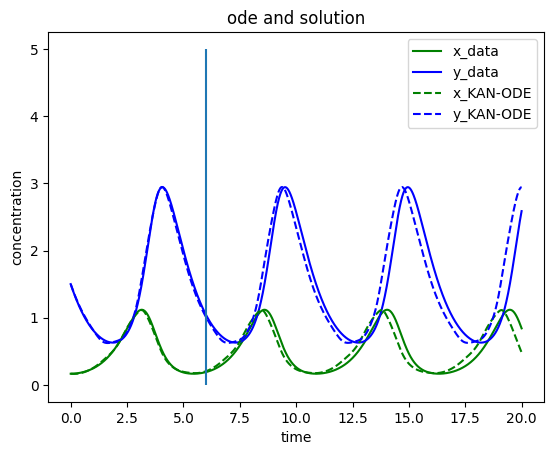

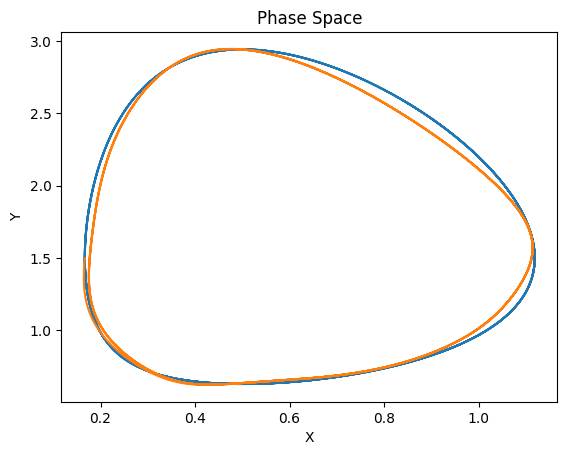

ICs: tensor([[0.1111, 1.5000]], requires_grad=True)


100%|██████████| 1000/1000 [25:24<00:00,  1.52s/it]


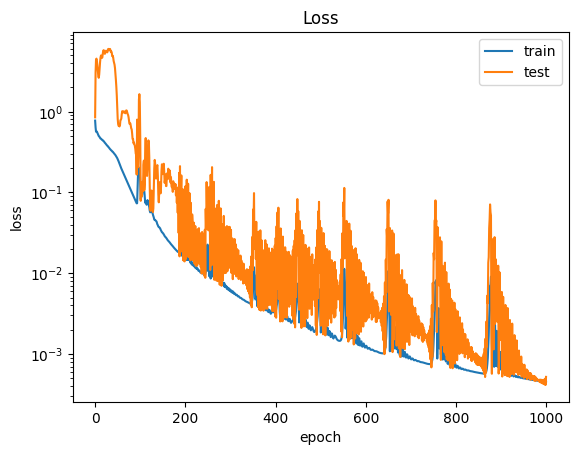

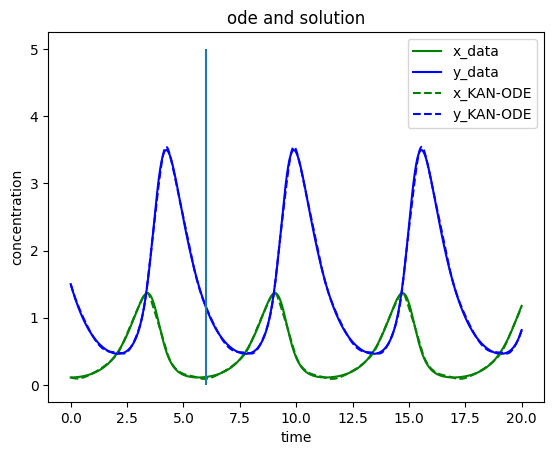

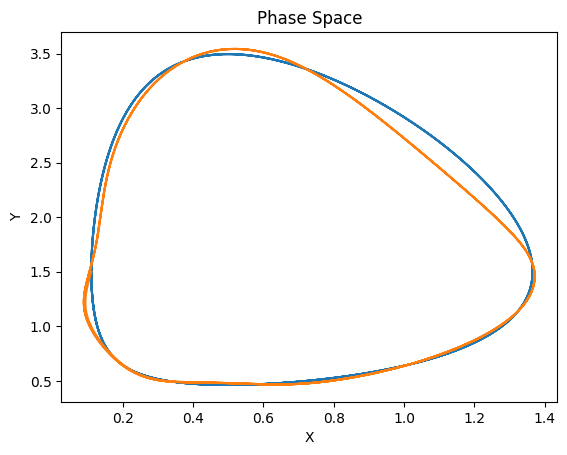

ICs: tensor([[0.0556, 1.5000]], requires_grad=True)


100%|██████████| 1000/1000 [27:52<00:00,  1.67s/it]


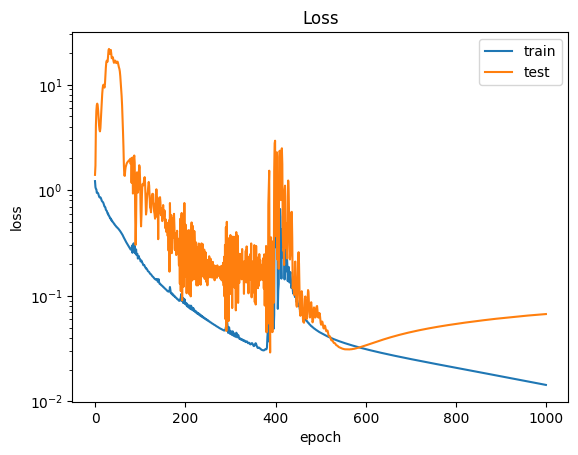

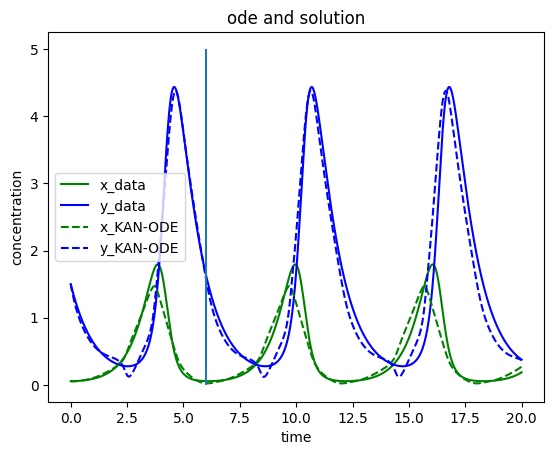

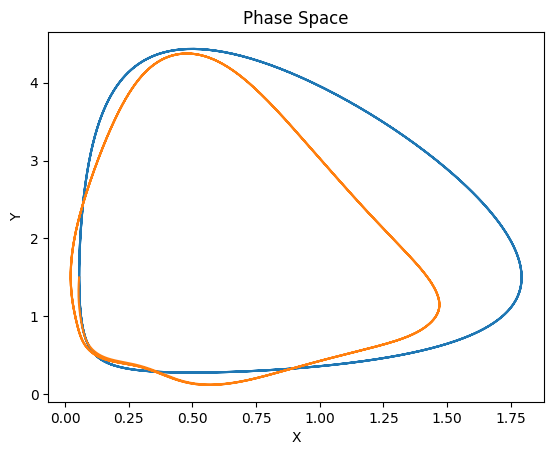

ICs: tensor([[0.0000, 1.5000]], requires_grad=True)


100%|██████████| 1000/1000 [16:31<00:00,  1.01it/s]


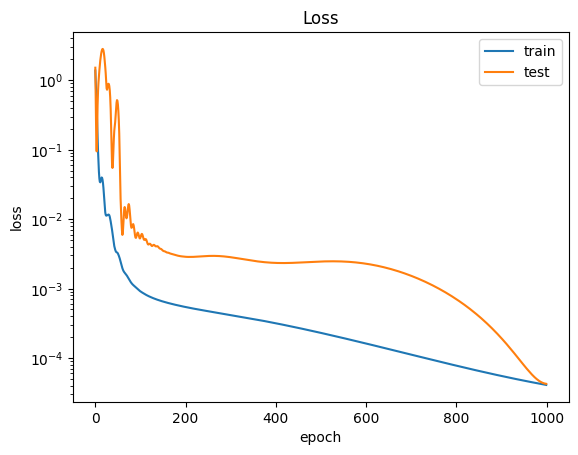

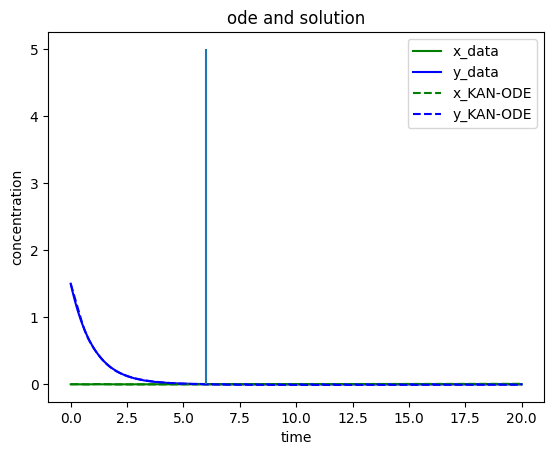

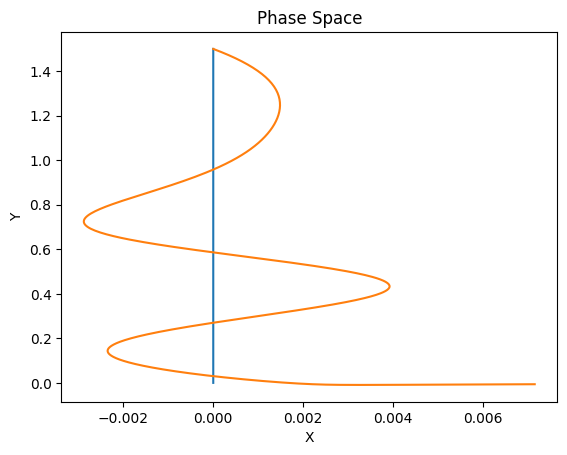

In [5]:
# main loop to test different inial conditions for the LV equation
xCoords = np.linspace(0.5, 0.0, 10)

# alpha, beta, delta, gamma
params = [1.5, 1, 2, 1]
X0 = [1, 1.5] # dummy X0 for initialisation 

kanODE = KANODE(model, pred_prey_deriv, X0, params, 20, 6, 1000)

for x in xCoords:
    X0 = [x, 1.5]
    kanODE.setOdeIC(X0)
    print(f"ICs: {kanODE.odeInitialState}")
    kanODE.train(1000)
    _, solution = kanODE.test()
    kanODE.plotLoss("Loss")
    kanODE.plotODE("ode and solution", solution[:, 0, :])
    kanODE.plotPhaseSpace("Phase Space", solution[:, 0, :])

    model = ChebyKAN([2, 10, 2], 4)
    kanODE.setModel(model)
